Build a prediction model using Machine Learning :
predict whether a customer will give a high review rating (4-5) or low rating (1-3)



In [ ]:
#importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [ ]:
#upload files or dataset
from google.colab import files
uploaded = files.upload()

Saving olist_customers_dataset.xlsx to olist_customers_dataset (1).xlsx
Saving olist_order_items_dataset.xlsx to olist_order_items_dataset (1).xlsx
Saving olist_order_payments_dataset.xlsx to olist_order_payments_dataset (1).xlsx
Saving olist_orders_dataset.xlsx to olist_orders_dataset (1).xlsx
Saving olist_products_dataset.xlsx to olist_products_dataset (1).xlsx
Saving olist_sellers_dataset.xlsx to olist_sellers_dataset (1).xlsx
Saving product_category_name_translation.xlsx to product_category_name_translation (1).xlsx


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving olist_order_reviews.xlsx to olist_order_reviews.xlsx


In [ ]:
#load the datasets
customers = pd.read_excel("olist_customers_dataset.xlsx")
orders = pd.read_excel("olist_orders_dataset.xlsx")
reviews = pd.read_excel("olist_order_reviews.xlsx")

In [ ]:
#merge the datasets
data = orders.merge(reviews, on="order_id")
data = data.merge(customers, on="customer_id")

In [ ]:
data.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,a54f0611adc9ed256b57ede6b6eb5114,4,NaN,"NÃ£o testei o produto ainda, mas ele veio corr...",2017-10-11,2017-10-12 03:43:48,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,8d5266042046a06655c8db133d120ba5,4,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,e73b67b67587f7644d5bd1a52deb1b01,5,NaN,NaN,2018-08-18,2018-08-22 19:07:58,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,359d03e676b3c069f62cadba8dd3f6e8,5,NaN,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,e50934924e227544ba8246aeb3770dd4,5,NaN,NaN,2018-02-17,2018-02-18 13:02:51,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP


In [ ]:
#select only useful columns
data = data[['order_purchase_timestamp',
             'order_delivered_customer_date',
             'review_score',
             'customer_state']]

In [ ]:
#convert date columns
data['order_purchase_timestamp'] = pd.to_datetime(data['order_purchase_timestamp'])
data['order_delivered_customer_date'] = pd.to_datetime(data['order_delivered_customer_date'])

In [ ]:
#create delivery time feature
data['delivery_time'] = (data['order_delivered_customer_date'] -
                         data['order_purchase_timestamp']).dt.days

In [ ]:
#remove missing values
data= data.dropna()

In [ ]:
#convert rating into classification
data['rating_class'] = data['review_score'].apply(lambda x: 1 if x >= 4 else 0)

In [ ]:
#encode state column
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['customer_state'] = le.fit_transform(data['customer_state'])

In [ ]:
#define x and y
X = data[['delivery_time', 'customer_state']]
y = data['rating_class']

In [ ]:
#Train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
#Train the model
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train, y_train)

RandomForestClassifier()

In [ ]:
#prediction
y_pred = model.predict(X_test)

In [ ]:
#accuracy
from sklearn.metrics import accuracy_score

accuracy_score(y_test, y_pred)

0.8088418430884184

In [ ]:
#model evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.8088418430884184


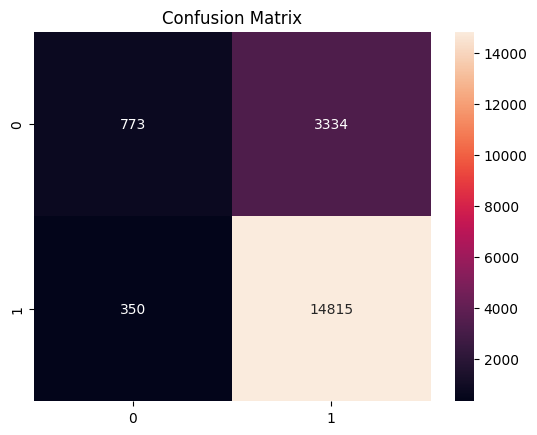

In [ ]:
#confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Model Performance:
A Machine Learning model was developed using the Olist e-commerce dataset to predict customer review ratings based on delivery time and customer location.The Random Forest classification model achieved an accuracy of approximately 81% on the test dataset. The confusion matrix shows that the model performs very well in predicting high customer ratings and reasonably well in predicting low ratings.

## Insights:
1. The results indicate that delivery time and customer location have a strong impact on customer satisfaction.

2. Faster deliveries are more likely to result in higher review ratings.